In [535]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [536]:
# Load dataset
# Display first few rows
df = pd.read_csv("/content/superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [537]:
# Basic info about dataset
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [538]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [539]:
# Summary statistics
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [540]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

Duplicate rows: 0


In [541]:
# Column '记录数' was dropped because it is not useful for the analysis.
df = df.drop(columns=['记录数'])

In [542]:
# CREATE CLASSIFICATION TARGET
df["Profit_Label"] = np.where(df["Profit"] > 0, 1, 0)

print("Profit_Label created successfully.")
display(df[["Profit", "Profit_Label"]].head())

Profit_Label created successfully.


,Profit,Profit_Label
0,9.3312,1
1,9.2928,1
2,9.8418,1
3,53.2608,1
4,3.1104,1


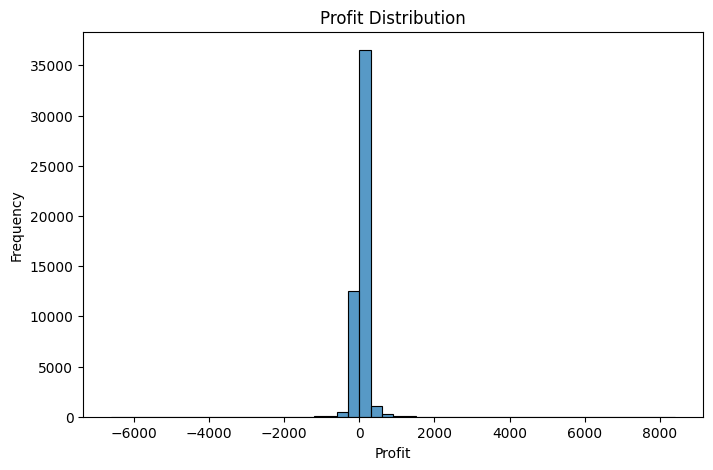

In [543]:
#Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=50)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

Most transactions generate small profits, but some result in large losses or gains.

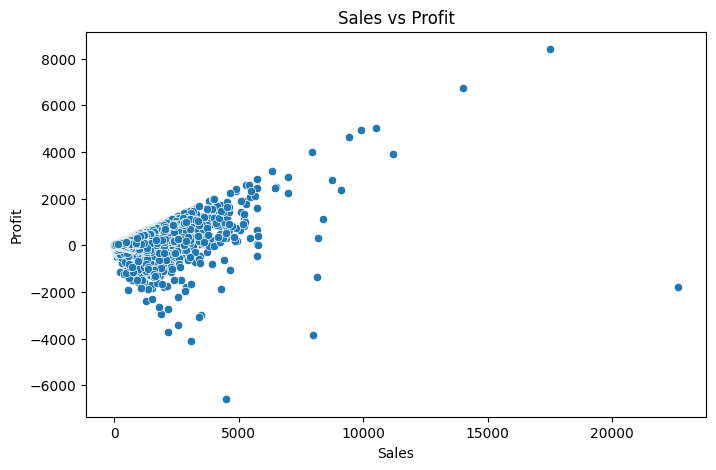

In [544]:
#Sales VS Profit
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

Higher sales do not always lead to higher profit,suggesting that other factors such as discounting and cost structure influence profitability.

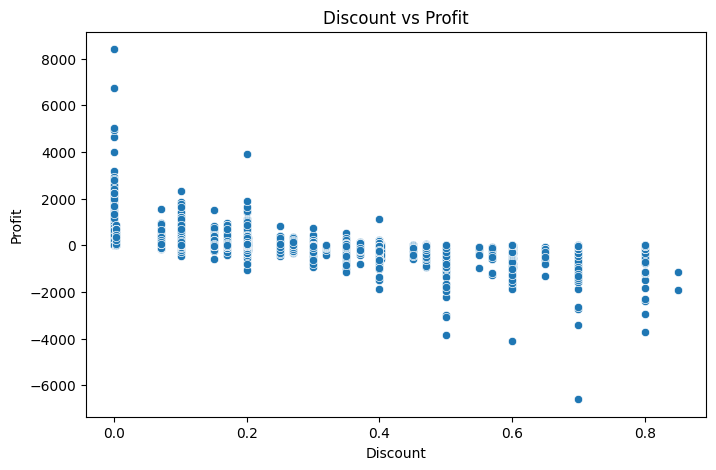

In [545]:
# DISCOUNT VS PROFIT
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

There is a generally negative relationship between discount and profit.

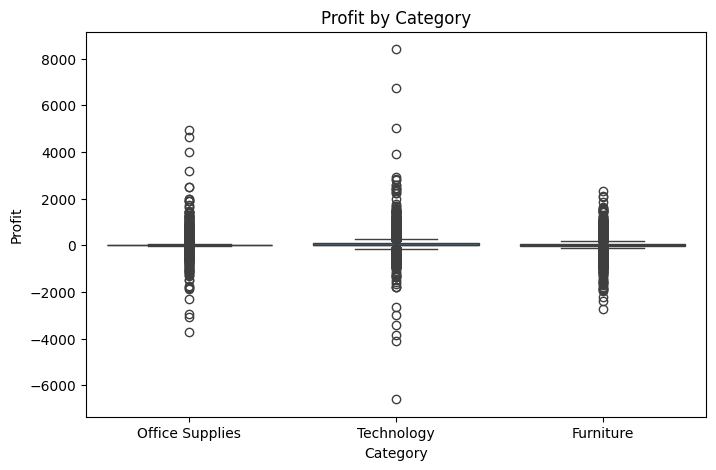

In [546]:
# PROFIT BY CATEGORY
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

Profitability differs across product categories.

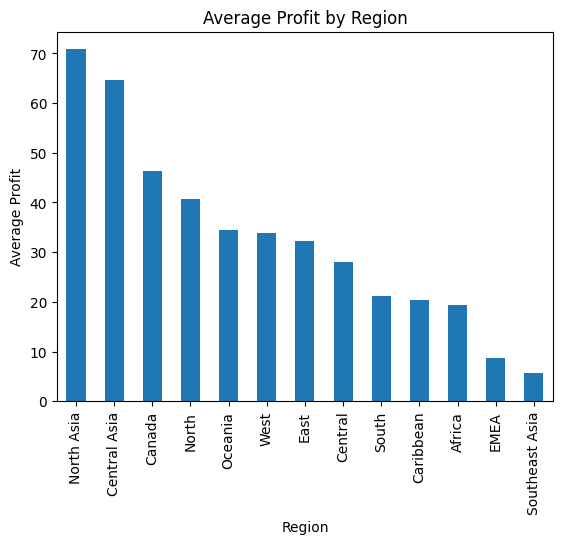

In [547]:
# PROFIT BY REGION
region_profit = df.groupby("Region")["Profit"].mean().sort_values(ascending=False)
region_profit.plot(kind="bar")
plt.title("Average Profit by Region")
plt.xlabel("Region")
plt.ylabel("Average Profit")
plt.show()

Profit differs across regions, suggesting that geographic context may influence performance.

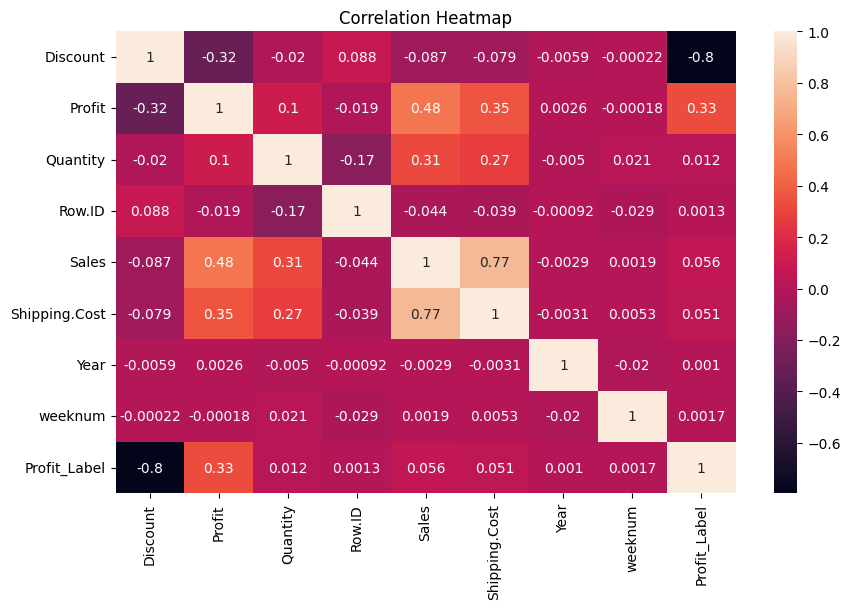

In [548]:
# CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

 Discount shows a negative relationship with profit. Correlation indicates association, not causation.

We selected Sales, Discount, and Quantity because they directly impact revenue and cost.

Category and Region were excluded initially to:
- Reduce model complexity
- Avoid encoding overhead
- Maintain interpretability

In [549]:
X = df[['Sales', 'Discount', 'Quantity']]
y = df['Profit']

In [550]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Regression training set shape:", X_train.shape)
print("Regression testing set shape:", X_test.shape)

Regression training set shape: (41032, 3)
Regression testing set shape: (10258, 3)


In [551]:
#Baseline Regression
baseline_pred = [y_train.mean()] * len(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Regression Results")
print("RMSE:", round(baseline_rmse, 2))
print("R²:", round(baseline_r2, 2))

Baseline Regression Results
RMSE: 171.43
R²: -0.0


In [552]:
# LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)


print("Linear Regression Results")
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 2))

Linear Regression Results
RMSE: 156.32
R²: 0.17


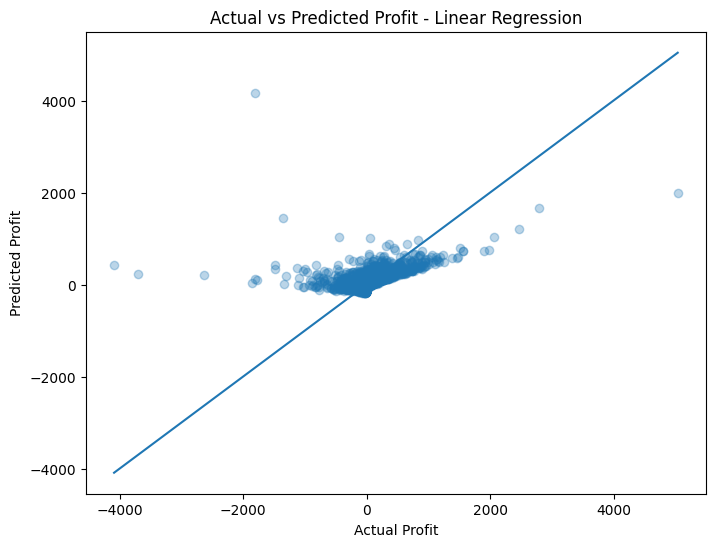

In [553]:
# ACTUAL VS PREDICTED - LINEAR REGRESSION
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Profit - Linear Regression")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.show()

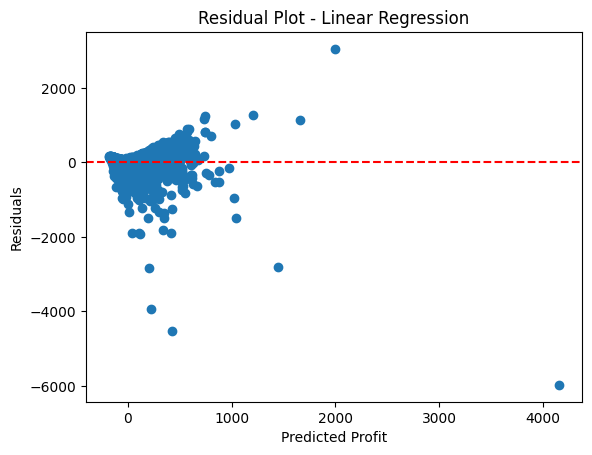

In [554]:
# LINEAR REGRESSION RESIDUAL PLOT
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.show()

The R² value (~0.17) indicates that the model explains only a small portion of variance.

This suggests:
- Linear relationships are weak
- Important variables are missing

Residual patterns indicate violation of assumptions.

In [555]:
# DECISION TREE REGRESSION
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results")
print("RMSE:", round(rmse_dt, 2))
print("R²:", round(r2_dt, 2))

Decision Tree Regression Results
RMSE: 120.26
R²: 0.51


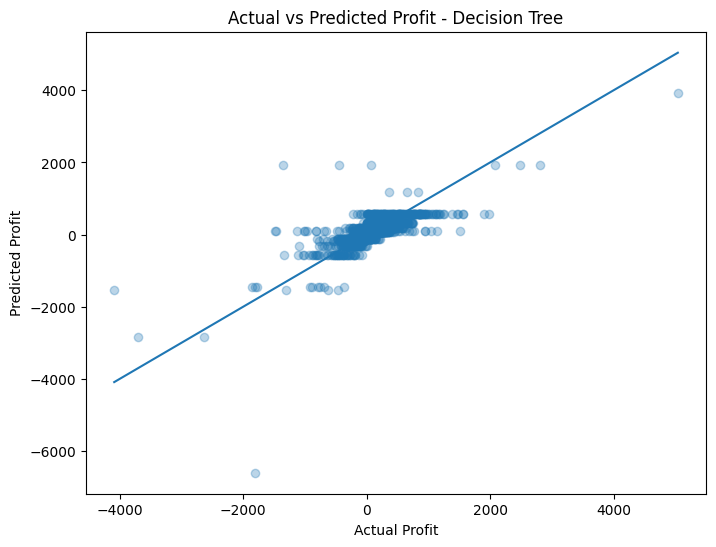

In [556]:
# ACTUAL VS PREDICTED - DECISION TREE
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Profit - Decision Tree")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.show()

The Decision Tree model performs better because it can capture nonlinear relationships between variables, which are not handled well by Linear Regression.

In [557]:
# REGRESSION COMPARISON
regression_results = pd.DataFrame({
    "Model": ["Baseline Regression", "Linear Regression", "Decision Tree Regression"],
    "RMSE": [baseline_rmse, rmse_lr, rmse_dt],
    "R2": [baseline_r2, r2_lr, r2_dt]
})

display(regression_results)

,Model,RMSE,R2
0,Baseline Regression,171.430622,-0.000239
1,Linear Regression,156.322311,0.168295
2,Decision Tree Regression,120.264210,0.507734


In [558]:
# CLASSIFICATION DATA PREPARATION
df['Profit_Label'] = np.where(df['Profit'] > 0, 1, 0)

X_cls = df[['Sales','Discount','Quantity']]
y_cls = df['Profit_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [559]:
# BASELINE CLASSIFICATION
from sklearn.dummy import DummyRegressor, DummyClassifier
baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(X_train, y_train)

baseline_pred_cls = baseline_clf.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred_cls)
baseline_prec = precision_score(y_test, baseline_pred_cls, zero_division=0)
baseline_rec = recall_score(y_test, baseline_pred_cls, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred_cls, zero_division=0)

print("Baseline Classification Results")
print("Accuracy:", round(baseline_acc, 4))
print("Precision:", round(baseline_prec, 4))
print("Recall:", round(baseline_rec, 4))
print("F1-score:", round(baseline_f1, 4))

Baseline Classification Results
Accuracy: 0.7412
Precision: 0.7412
Recall: 1.0
F1-score: 0.8514


Logistic Regression is used because it is suitable for binary classification and provides an interpretable baseline model. The higher `max_iter` value is used to ensure convergence.

In [560]:
# LOGISTIC REGRESSION
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred = log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9185026320920258
Precision: 0.9195288282703038
Recall: 0.9754044456135735
F1: 0.946642838907327


In [561]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2655
           1       0.92      0.98      0.95      7603

    accuracy                           0.92     10258
   macro avg       0.92      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258



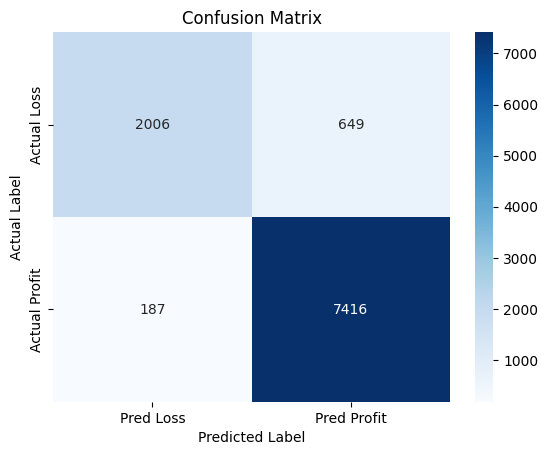

[[2006  649]
 [ 187 7416]]


In [562]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Loss", "Pred Profit"],
            yticklabels=["Actual Loss", "Actual Profit"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(cm)

The confusion matrix helps interpret the model in business terms.

- **False Positive:** A transaction is predicted to be profitable, but it actually results in a loss. This is risky because it may lead to poor pricing or discount decisions.
- **False Negative:** A transaction is predicted to be loss-making, but it would actually have been profitable. This may lead to missed opportunities.

In this project, false positives are more concerning because they can directly support unprofitable business decisions.

In [563]:
# CLASSIFICATION COMPARISON
classification_results = pd.DataFrame({
    "Model": ["Baseline Classification", "Logistic Regression"],
    "Accuracy": [baseline_acc, accuracy_score(y_test, y_pred)],
    "Precision": [baseline_prec, precision_score(y_test, y_pred)],
    "Recall": [baseline_rec, recall_score(y_test, y_pred)],
    "F1-score": [baseline_f1, f1_score(y_test, y_pred)]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Classification,0.741178,0.741178,1.000000,0.851352
1,Logistic Regression,0.918503,0.919529,0.975404,0.946643


The analysis shows that discount is a key factor influencing profit.

Decision Tree models outperform Linear Regression, indicating nonlinear relationships.

While models provide insights, their predictive power is moderate and should be used cautiously in decision-making.

#Key Findings
The analysis produced several important findings:

1. Discount has a clear negative relationship with profit.
2. Higher sales do not always result in higher profitability.
3. Profit varies across product categories and regions.
4. Linear Regression explains only a limited portion of variation in profit.
5. Decision Tree Regression performs better, suggesting nonlinear patterns in the data.
6. Logistic Regression provides strong classification performance, but business interpretation of prediction errors remains important.

#Limitations

This project has several limitations:

- Only a limited set of predictors was used in the models.
- The dataset does not include customer-level behavior or more detailed cost-related variables.
- The models identify patterns but do not establish causation.
- Linear Regression may not satisfy all assumptions.
- Decision Trees may overfit if not controlled properly.
- Classification metrics should be interpreted carefully in the context of business costs.

#Final Conclusion

This analysis shows that discount has a strong negative impact on profit and that profit is influenced by multiple factors. Linear Regression provides limited predictive power, while Decision Tree Regression performs better because it captures nonlinear relationships more effectively. Logistic Regression also demonstrates that profitable and loss-making transactions can be classified with strong performance.

Overall, predictive analytics can support retail decision-making, especially in pricing and discount strategy, but the models should be used carefully and improved further with additional features and more advanced methods.